ValueError: (1.0, 0.0, 0.0, 0.6) is not in list

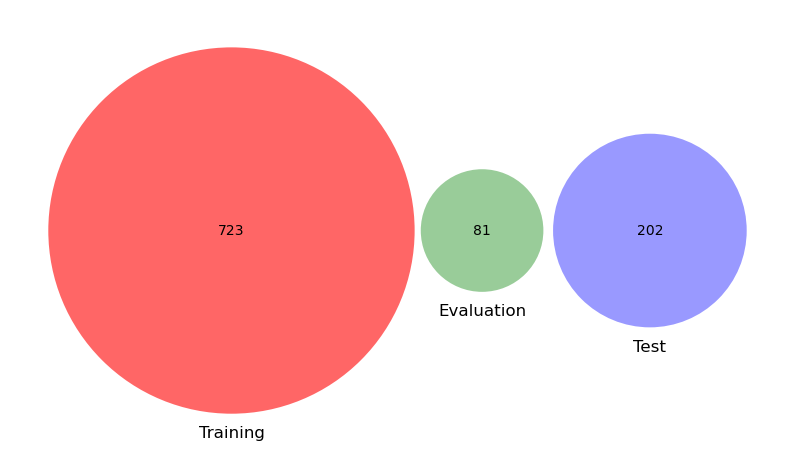

In [1]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
from matplotlib.patches import Circle

# Erstellen der Figur und der Achsen
fig, ax = plt.subplots(figsize=(10, 8))

# Erstellen des Venn-Diagramms
v = venn3(subsets=(723, 81, 0, 202, 0, 0, 0), set_labels=('Training', 'Evaluation', 'Test'))

# Anpassen der Kreisfarben und Transparenz
for id in ('100', '010', '001'):
    v.get_patch_by_id(id).set_alpha(0.6)
    v.get_patch_by_id(id).set_color(plt.cm.tab10(["blue", "orange", "green"].index(v.get_patch_by_id(id).get_facecolor())))

# Anpassen der Textfarben und Größen
for text in v.set_labels:
    text.set_fontsize(16)
for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(14)

# Hinzufügen eines umschließenden Kreises für den Gesamtdatensatz
total_circle = Circle((0, 0), 0.6, fill=False, ec="gray", linestyle="--")
ax.add_artist(total_circle)

# Hinzufügen eines Titels für den Gesamtdatensatz
plt.text(0, 0.7, "Gesamtdatensatz\n(1006 Dateien)", ha='center', va='center', fontsize=16, fontweight='bold')

# Entfernen der Achsen
ax.axis('off')

# Hinzufügen eines Titels
plt.title("Aufteilung des Datensatzes", fontsize=20, fontweight='bold', pad=20)

# Anzeigen des Diagramms
plt.tight_layout()
plt.show()

C:\Users\e-aut\anaconda3\envs\scipy\Lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


AttributeError: 'NoneType' object has no attribute 'set_text'

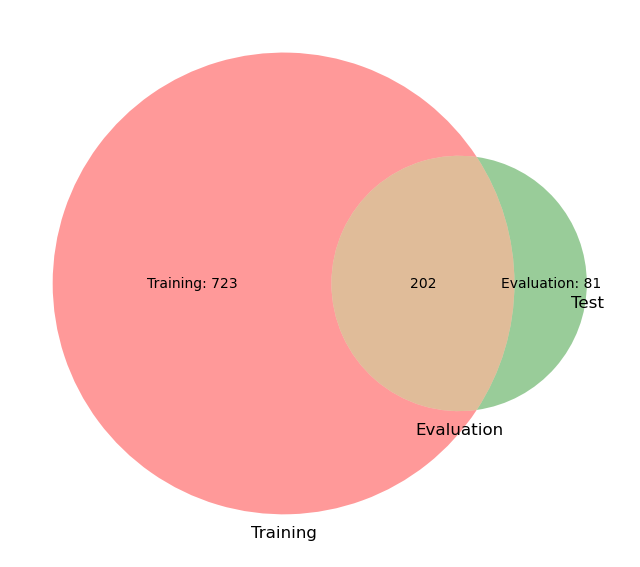

In [2]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Größen der verschiedenen Datensätze
train_files = 723
eval_files = 81
test_files = 202

# Erstellen des Venn-Diagramms
plt.figure(figsize=(8, 8))

# Venn-Diagramm für drei Datensätze
venn = venn3(subsets=(train_files, eval_files, test_files, 0, 0, 0, 0),
             set_labels=('Training', 'Evaluation', 'Test'))

# Anpassen der Farben
venn.get_label_by_id('100').set_text(f'Training: {train_files}')
venn.get_label_by_id('010').set_text(f'Evaluation: {eval_files}')
venn.get_label_by_id('001').set_text(f'Test: {test_files}')

# Titel hinzufügen
plt.title("Venn Diagram of Data Distribution (Training, Evaluation, Test)")

# Diagramm anzeigen
plt.show()


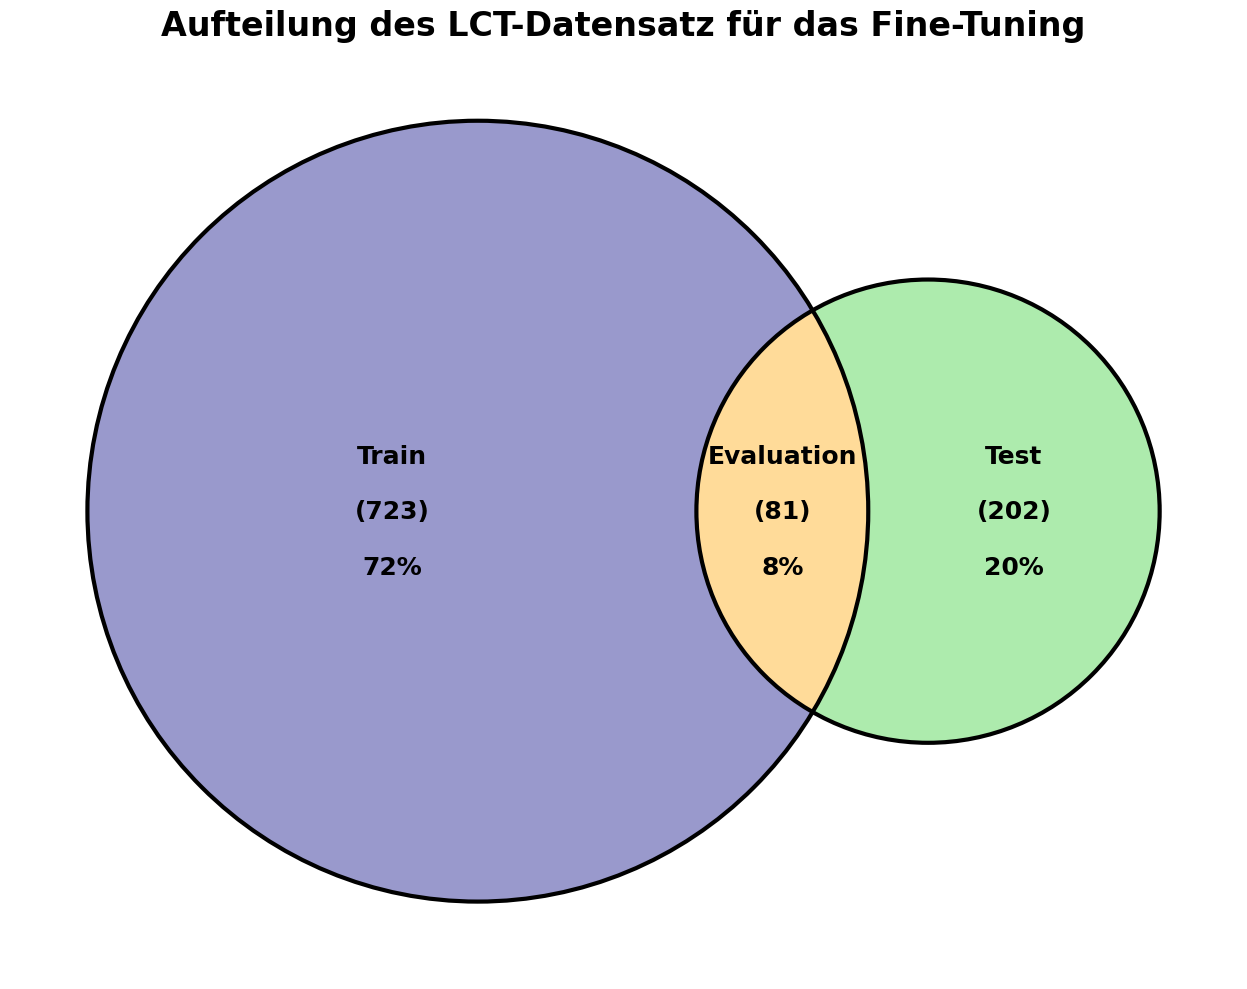

In [20]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import numpy as np

# Datensatzgrößen
test = 202
train = 723
evaluation = 81
total = test + train + evaluation

# Prozentuale Anteile berechnen
test_percent = round(test / total * 100)
train_percent = round(train / total * 100)
evaluation_percent = round(evaluation / total * 100)

# Erstellen der Figur
plt.figure(figsize=(14, 10))

# Venn-Diagramm erstellen (Train links, Test rechts)
v = venn2(subsets=(train, test, evaluation), set_labels=('', ''))

# Farben anpassen
v.get_patch_by_id('10').set_color('navy')
v.get_patch_by_id('01').set_color('limegreen')
v.get_patch_by_id('11').set_color('orange')

# Funktion zum Formatieren der Labels mit Zeilenumbrüchen
def format_label(name, count, percent):
    return f'{name}\n\n({count})\n\n{percent}%'

# Beschriftungen anpassen und fett machen
for id, (name, count, percent) in zip(['10', '01', '11'],
                                      [('Train', train, train_percent),
                                       ('Test', test, test_percent),
                                       ('Evaluation', evaluation, evaluation_percent)]):
    label = v.get_label_by_id(id)
    label.set_text(format_label(name, count, percent))
    label.set_fontsize(18)  # Schriftgröße erhöht
    label.set_fontweight('bold')
    label.set_color('black')  # Für bessere Sichtbarkeit

# Schriftgröße der Set-Labels anpassen
for label in v.set_labels:
    label.set_fontsize(20)  # Schriftgröße erhöht
    label.set_fontweight('bold')

# Kreise hervorheben
venn2_circles(subsets=(train, test, evaluation), linewidth=3)

# Titel hinzufügen
plt.title("Aufteilung des LCT-Datensatz für das Fine-Tuning", fontsize=24, fontweight='bold')  # Schriftgröße erhöht

# Diagramm als PDF speichern
plt.tight_layout()
plt.savefig('lct_venn.pdf', format='pdf', bbox_inches='tight')
plt.savefig(f'test.png')

plt.show()